# Business Understanding

## Project Domain

Prediksi pendapatan individu berdasarkan data sensus demografis dan sosial ekonomi.

## Problem Statements

Bagaimana memprediksi apakah seseorang berpenghasilan lebih dari $50.000 per tahun menggunakan data sensus?

## Goals

Membangun model klasifikasi untuk menentukan tingkat pendapatan individu.

## Solution Statements

Menggunakan algoritma machine learning untuk memprediksi pendapatan berdasarkan fitur seperti usia, pendidikan, jam kerja, dan bobot populasi.

# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"muhammadadnanall","key":"5f09fe3b566e42495639c5770f0647b8"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d uciml/adult-census-income

Dataset URL: https://www.kaggle.com/datasets/uciml/adult-census-income
License(s): CC0-1.0


In [4]:
!mkdir adult-census-income
!unzip adult-census-income.zip -d adult-census-income
!ls adult-census-income

Archive:  adult-census-income.zip
  inflating: adult-census-income/adult.csv  
adult.csv


## Import Library yang dibutuhkan

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Exploratory Data Analysis


In [6]:
df = pd.read_csv('adult-census-income/adult.csv')

In [7]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [9]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


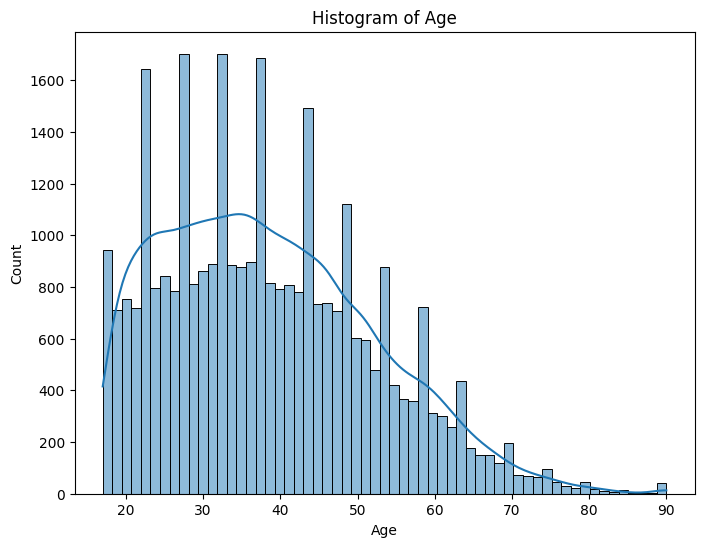

In [10]:
#Histogram
plt.figure(figsize=(8,6))
sns.histplot(df['age'], kde=True)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.show()

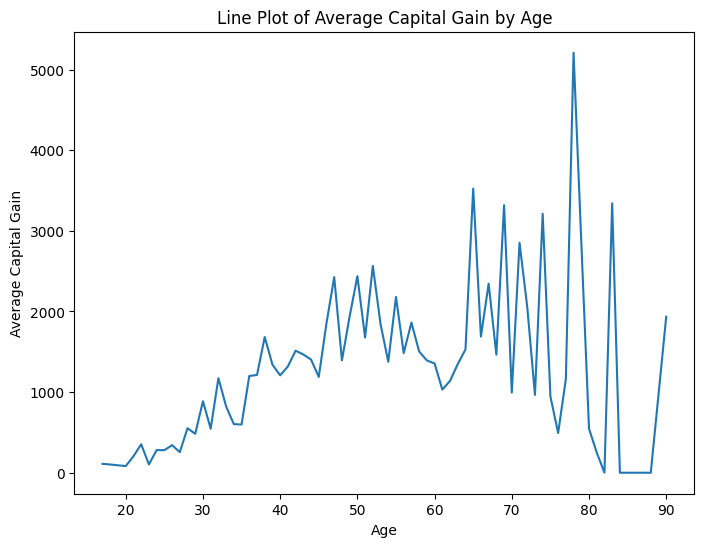

In [11]:
avg_capital_gain_by_age = df.groupby('age')['capital.gain'].mean()
plt.figure(figsize=(8, 6))
plt.plot(avg_capital_gain_by_age.index, avg_capital_gain_by_age.values)
plt.title('Line Plot of Average Capital Gain by Age')
plt.xlabel('Age')
plt.ylabel('Average Capital Gain')
plt.show()

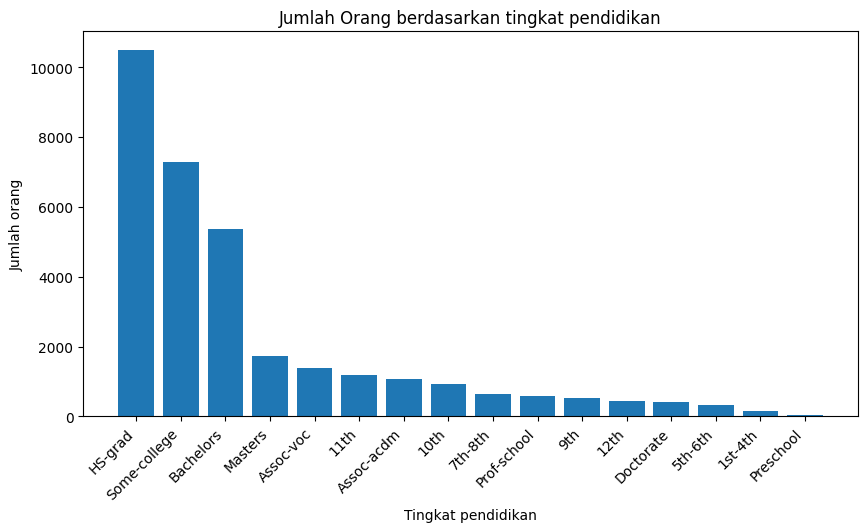

In [12]:
# Bar Chart
# Contoh: Melihat jumlah orang berdasarkan tingkat pendidikan
education_counts = df['education'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(education_counts.index, education_counts.values)
plt.title('Jumlah Orang berdasarkan tingkat pendidikan')
plt.xlabel('Tingkat pendidikan')
plt.ylabel('Jumlah orang')
plt.xticks(rotation=45, ha='right')
plt.show()

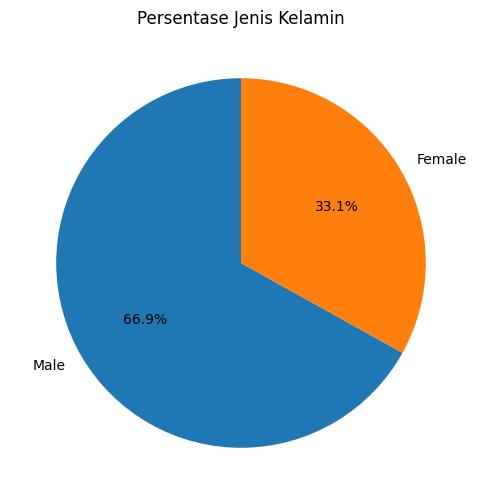

In [13]:
sex_counts = df['sex'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Persentase Jenis Kelamin')
plt.show()

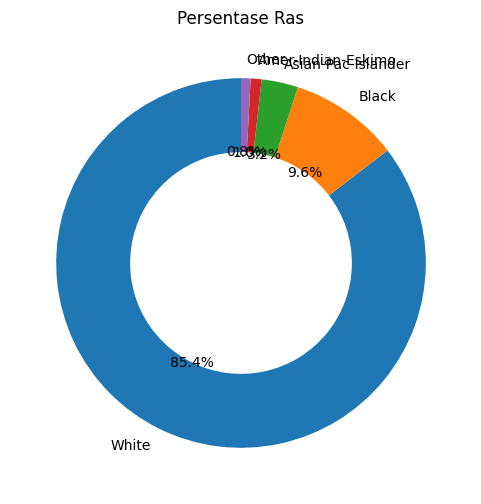

In [14]:
# Donut Chart
# Contoh: Melihat persentase ras
race_counts = df['race'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(race_counts.values, labels = race_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.4))
plt.title('Persentase Ras')
plt.show()

# Data Preparation

In [15]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

In [16]:
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [17]:
X = df.drop(columns='income')
y = df['income']

In [18]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [20]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [21]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

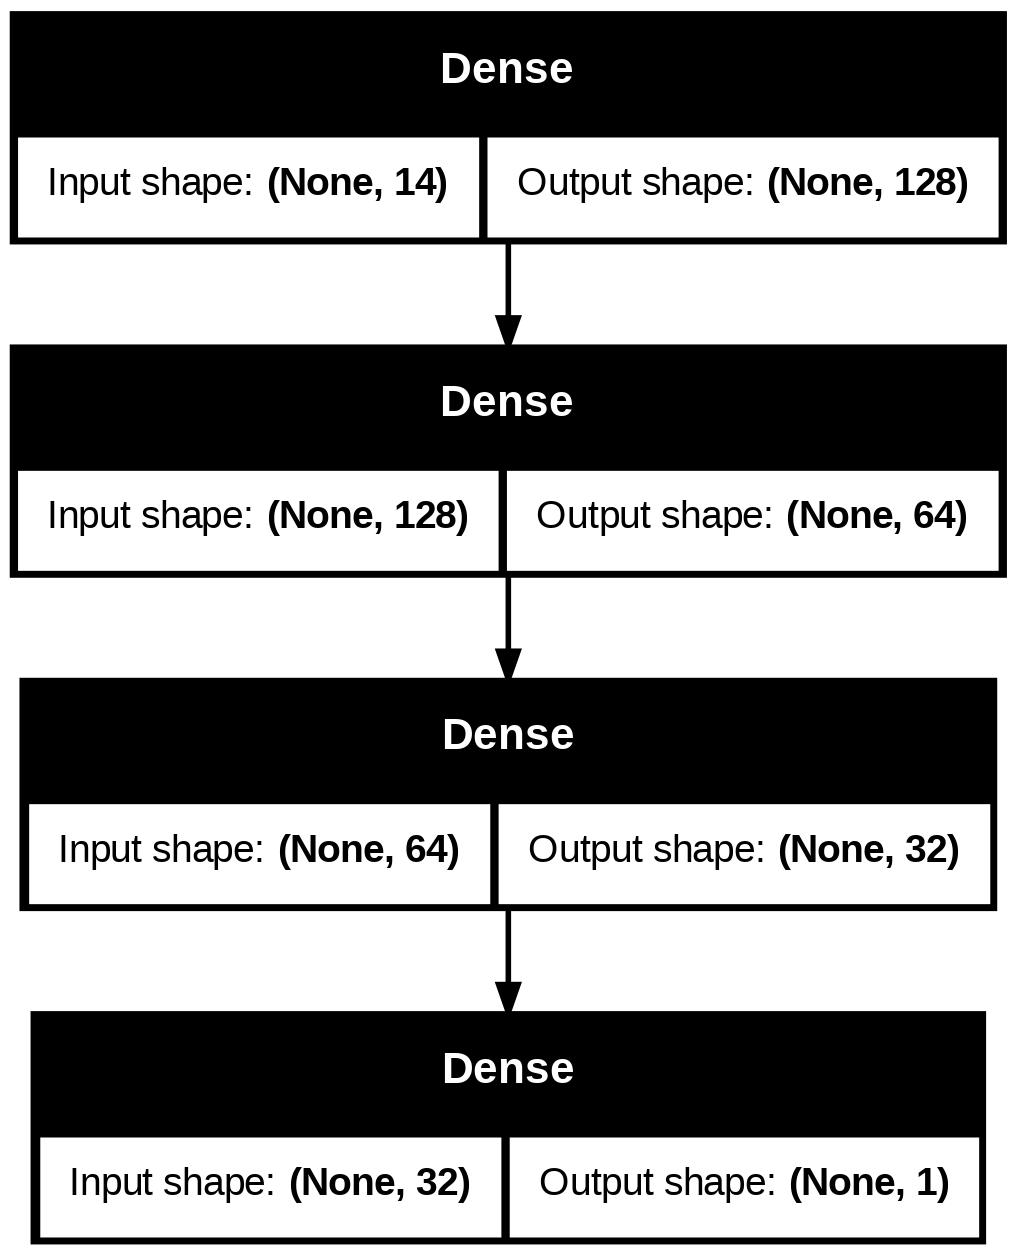

In [23]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [24]:
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/100
1509/1509 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7963 - loss: 0.4371 - val_accuracy: 0.8309 - val_loss: 0.3557
Epoch 2/100
1509/1509 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8353 - loss: 0.3520 - val_accuracy: 0.8122 - val_loss: 0.3780
Epoch 3/100
1509/1509 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8399 - loss: 0.3422 - val_accuracy: 0.8298 - val_loss: 0.3494
Epoch 4/100
1509/1509 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8356 - loss: 0.3414 - val_accuracy: 0.8392 - val_loss: 0.3544
Epoch 5/100
1509/1509 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8438 - loss: 0.3332 - val_accuracy: 0.8369 - val_loss: 0.3454
Epoch 6/100
1509/1509 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8411 - loss: 0.3355 - val_accuracy: 0.8376 - val_loss: 0.3448
Epoch 7/100
1509/1509 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8428 - loss: 0.3327 - val_accuracy: 0.8351 - val_loss: 0.3513
Epoch 8/100
1509/1509 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8390 - loss: 

## Evaluation

In [25]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8397 - loss: 0.4475
Akurasi Model: 0.8440
Loss Model: 0.4248


In [26]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

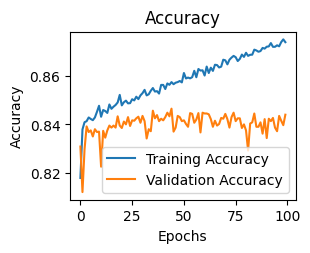

In [27]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

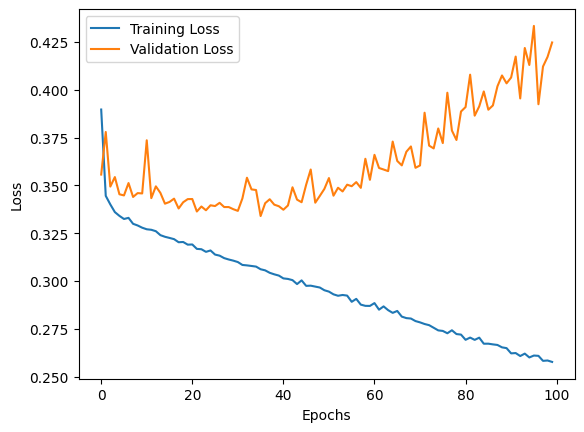

In [28]:
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


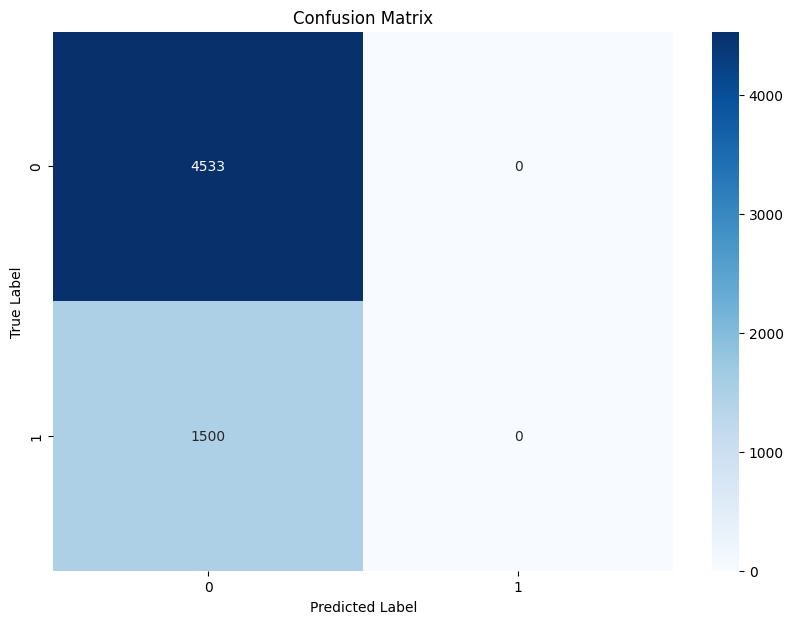

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      4533
           1       0.00      0.00      0.00      1500

    accuracy                           0.75      6033
   macro avg       0.38      0.50      0.43      6033
weighted avg       0.56      0.75      0.64      6033



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [30]:
sample_input = np.array([[39, 40, 13, 2174, 0, 0, 40, 0, 9, 1, 4, 0, 2174, 0]]) # Update with correct number of features
sample_input_df = pd.DataFrame(sample_input, columns=X.columns)

In [31]:
sample_input_scaled = scaler.transform(sample_input_df)

In [32]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"Prediksi: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Prediksi: <=50K


## Save Model

In [33]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('adult_census.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp1a97gi0e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 14), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136785602182224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784421039056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784421039440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784421040016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784421037520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784421039824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784421036176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784421035792: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [34]:
import joblib
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']